In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt

data = pd.read_csv('Location1.csv')
data.head()
data['Time'] = pd.to_datetime(data['Time'])
data['hour'] = data['Time'].dt.hour
data['day_of_week'] = data['Time'].dt.dayofweek
data['month'] = data['Time'].dt.month

features = [
    'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 
    'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 
    'winddirection_100m', 'windgusts_10m', 'hour', 'day_of_week', 'month'
]
target = 'Power'
X = data[features]
y = data[target]


In [2]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

y_pred = model.predict(X_test_scaled)

mae_linear = mean_absolute_error(y_test_scaled, y_pred)
mse_linear = mean_squared_error(y_test_scaled, y_pred)
r2_linear = r2_score(y_test_scaled, y_pred)
print(f"Linear Regression - MAE: {mae_linear}, MSE: {mse_linear},{r2_linear}")

Linear Regression - MAE: 0.14062722008259482, MSE: 0.03179257274279978,0.6224670470295204


In [5]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_scaled)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test_scaled, y_pred_poly)
mse_poly = mean_squared_error(y_test_scaled, y_pred_poly)
r2_poly = r2_score(y_test_scaled, y_pred_poly)
print(f"Polynomial Regression - MAE: {mae_poly}, MSE: {mse_poly},{r2_poly}")

Polynomial Regression - MAE: 0.1364707130404405, MSE: 0.03016331267520909,0.641814313117437


In [6]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_scaled, y_train_scaled)
y_pred_knn = knn_regressor.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test_scaled, y_pred_knn)
mse_knn = mean_squared_error(y_test_scaled, y_pred_knn)
r2_knn = r2_score(y_test_scaled, y_pred_knn)

print(f"KNN Regression - MAE: {mae_knn}, MSE: {mse_knn},{r2_knn}")

KNN Regression - MAE: 0.08232827194767997, MSE: 0.013860315955656203,0.8354104257565056


In [ ]:
results_linear = pd.DataFrame({
    'True Power (kW)': y_test.values,
    'Predicted Power (kW) - Linear Regression': scaler_y.inverse_transform(y_pred).flatten()
})

plt.figure(figsize=(12, 6))
plt.scatter(results_linear['True Power (kW)'], results_linear['Predicted Power (kW) - Linear Regression'], alpha=0.5, label='Predicted (Linear Regression)')
plt.plot([results_linear['True Power (kW)'].min(), results_linear['True Power (kW)'].max()],
         [results_linear['True Power (kW)'].min(), results_linear['True Power (kW)'].max()],
         color='red', label='Ideal Fit')
plt.title('True vs Predicted Power Output - Linear Regression')
plt.xlabel('True Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.legend()
plt.show()


results_knn = pd.DataFrame({
    'True Power (kW)': y_test.values,
    'Predicted Power (kW) - KNN Regression': scaler_y.inverse_transform(y_pred_knn).flatten()
})

plt.figure(figsize=(12, 6))
plt.scatter(results_knn['True Power (kW)'], results_knn['Predicted Power (kW) - KNN Regression'], alpha=0.5, label='Predicted (KNN Regression)')
plt.plot([results_knn['True Power (kW)'].min(), results_knn['True Power (kW)'].max()],
         [results_knn['True Power (kW)'].min(), results_knn['True Power (kW)'].max()],
         color='red', label='Ideal Fit')
plt.title('True vs Predicted Power Output - KNN Regression')
plt.xlabel('True Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.legend()
plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_scaled, y_train_scaled.flatten())

y_pred_rf = rf_regressor.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test_scaled, y_pred_rf)
mse_rf = mean_squared_error(y_test_scaled, y_pred_rf)
print(f" MAE: {mae_rf}, MSE: {mse_rf}")

 MAE: 0.10521218493588282, MSE: 0.02025063566434561


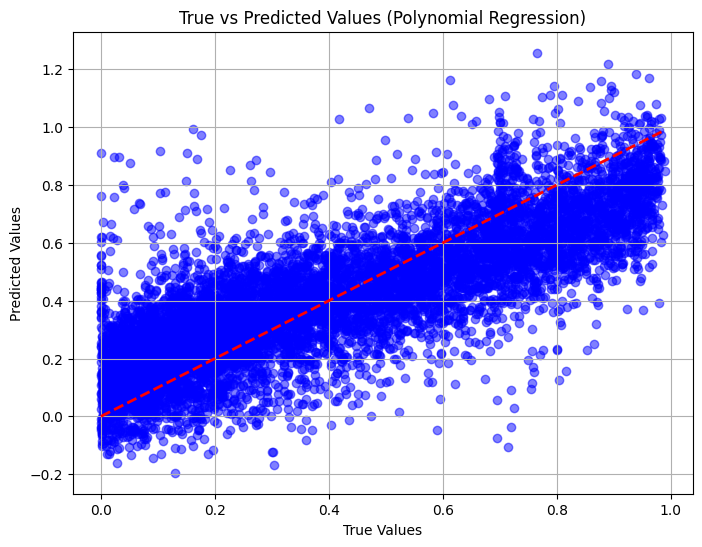

In [15]:
y_test_original = scaler_y.inverse_transform(y_test_scaled)
y_pred_poly_original = scaler_y.inverse_transform(y_pred_poly)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_poly_original, color='blue', alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         color='red', linestyle='--', linewidth=2)
plt.title('True vs Predicted Values (Polynomial Regression)')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid()
plt.show()


In [ ]:
results_rf = pd.DataFrame({
    'True Power (kW)': y_test.values,
    'Predicted Power (kW) - Random Forest': scaler_y.inverse_transform(y_pred_rf.reshape(-1, 1)).flatten()
})

plt.figure(figsize=(12, 6))
plt.scatter(results_rf['True Power (kW)'], results_rf['Predicted Power (kW) - Random Forest'], alpha=0.5, label='Predicted (Random Forest)')
plt.plot([results_rf['True Power (kW)'].min(), results_rf['True Power (kW)'].max()],
         [results_rf['True Power (kW)'].min(), results_rf['True Power (kW)'].max()],
         color='red', label='Ideal Fit')
plt.title('True vs Predicted Power Output - Random Forest')
plt.xlabel('True Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.legend()
plt.show()
